# Chapter 36 — Track-Aware Detection Filtering

## Goal

Use the preliminary tracks from Chapter 35 to identify detections that are temporally plausible and remove detections that look isolated, unstable, or biologically implausible.

## Inputs

```text
chapter34_top200_detections.csv
chapter35_track_nodes.csv
chapter35_track_edges.csv
chapter35_track_summary.csv
```

## Main output

```text
chapter36_filtered_detections.csv
```

The notebook also saves the complete temporal feature table and filtered track graph so later chapters can reuse the work without rerunning Chapters 34–36.


In [1]:

!pip install -q zarr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.8 MB/s eta 0:00:00


In [2]:

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
from IPython.display import display


In [3]:

@dataclass(frozen=True)
class FilteringConfig:
    sample_id: str = "44b6_12dfb391"
    node_match_radius: float = 6.0
    keep_fraction: float = 0.25
    maximum_reasonable_step_physical: float = 8.0
    maximum_reasonable_acceleration: float = 6.0
    train_timepoints: tuple[int, ...] = tuple(range(0, 60))
    validation_timepoints: tuple[int, ...] = tuple(range(60, 100))
    random_state: int = 42

CONFIG = FilteringConfig()
print(CONFIG)


FilteringConfig(sample_id='44b6_12dfb391', node_match_radius=6.0, keep_fraction=0.25, maximum_reasonable_step_physical=8.0, maximum_reasonable_acceleration=6.0, train_timepoints=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59), validation_timepoints=(60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99), random_state=42)


## Step 1 — Locate Chapter 34 and Chapter 35 Outputs


In [4]:

def find_file(filename: str) -> Path:
    roots = [Path("/kaggle/working"), Path("/kaggle/input"), Path(".")]

    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct

    matches = []
    for root in roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    if matches:
        return sorted(matches, key=lambda path: len(str(path)))[0]

    raise FileNotFoundError(
        f"Could not find '{filename}'. Attach the saved Chapter 34 and Chapter 35 outputs."
    )

chapter34_path = find_file("/kaggle/input/datasets/emailchrismathews/chapter35/chapter34_top200_detections.csv")
chapter35_nodes_path = find_file("/kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_nodes.csv")
chapter35_edges_path = find_file("/kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_edges.csv")
chapter35_summary_path = find_file("/kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_summary.csv")

print("Chapter 34:", chapter34_path)
print("Chapter 35 nodes:", chapter35_nodes_path)
print("Chapter 35 edges:", chapter35_edges_path)
print("Chapter 35 summary:", chapter35_summary_path)


Chapter 34: /kaggle/input/datasets/emailchrismathews/chapter35/chapter34_top200_detections.csv
Chapter 35 nodes: /kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_nodes.csv
Chapter 35 edges: /kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_edges.csv
Chapter 35 summary: /kaggle/input/datasets/emailchrismathews/chapter35/chapter35_track_summary.csv


In [5]:

detections_df = pd.read_csv(chapter34_path)
track_nodes_df = pd.read_csv(chapter35_nodes_path)
track_edges_df = pd.read_csv(chapter35_edges_path)
track_summary_df = pd.read_csv(chapter35_summary_path)

print("Detections:", len(detections_df))
print("Track nodes:", len(track_nodes_df))
print("Track edges:", len(track_edges_df))
print("Tracks:", len(track_summary_df))

display(detections_df.head())
display(track_nodes_df.head())
display(track_edges_df.head())


Detections: 20000
Track nodes: 20000
Track edges: 16455
Tracks: 3545


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,41,130,131,4.0,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,...,6.222860,1.625000,1660.5625,294.09106,1.7500,0,7.354238,-7.354238,1,chapter34_t0_0
1,24,123,85,4.0,3,large_sensitive|medium_sensitive|medium_strict,1279.0,1279.0,1216.271606,1353.0,...,7.320772,2.071477,1383.4375,293.54013,1.4375,0,7.437489,-7.437489,2,chapter34_t0_1
2,37,193,95,5.0,1,large_sensitive,1507.0,1507.0,1466.740723,1611.0,...,5.935492,1.723573,1556.0625,249.27237,1.4375,0,7.584010,-7.584010,3,chapter34_t0_2
3,17,255,95,5.0,1,large_sensitive,1195.0,1195.0,1210.688843,1365.0,...,9.283495,2.071477,1226.3125,199.05817,1.5000,0,7.949785,-7.949785,4,chapter34_t0_3
4,25,125,88,3.5,1,medium_sensitive,1192.0,1192.0,1120.629639,1292.0,...,7.531094,1.625000,1371.1875,286.81174,1.5625,0,8.260656,-8.260656,5,chapter34_t0_4


,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist
0,6,chapter34_t0_6,0,41.0,130.0,135.0,66.625,52.81250,54.84375,7,8.838406
1,28,chapter34_t0_28,0,22.0,190.0,59.0,35.750,77.18750,23.96875,29,11.861735
2,32,chapter34_t0_32,0,41.0,121.0,127.0,66.625,49.15625,51.59375,33,12.491119
3,34,chapter34_t0_34,0,38.0,130.0,133.0,61.750,52.81250,54.03125,35,12.895166
4,48,chapter34_t0_48,0,26.0,192.0,62.0,42.250,78.00000,25.18750,49,15.233347


,track_id,source_detection_id,target_detection_id,source_t,target_t,frame_gap,assignment_cost
0,0,chapter34_t0_0,chapter34_t1_66,0,1,1,3.509804
1,2,chapter34_t0_2,chapter34_t1_6,0,1,1,5.884148
2,3,chapter34_t0_3,chapter34_t1_95,0,1,1,1.327969
3,5,chapter34_t0_5,chapter34_t1_1,0,1,1,6.903031
4,7,chapter34_t0_7,chapter34_t1_64,0,1,1,2.989084


## Step 2 — Validate the Inputs


In [6]:

required_detection_columns = [
    "detection_id", "t", "z", "y", "x", "rank_position", "pred_dist"
]
missing_detection_columns = [
    column for column in required_detection_columns if column not in detections_df.columns
]
if missing_detection_columns:
    raise KeyError("Chapter 34 detections are missing: " + ", ".join(missing_detection_columns))

required_node_columns = ["track_id", "detection_id", "t", "z", "y", "x"]
missing_node_columns = [
    column for column in required_node_columns if column not in track_nodes_df.columns
]
if missing_node_columns:
    raise KeyError("Chapter 35 track nodes are missing: " + ", ".join(missing_node_columns))

unknown_track_nodes = set(track_nodes_df["detection_id"]) - set(detections_df["detection_id"])
if unknown_track_nodes:
    raise ValueError(
        f"{len(unknown_track_nodes)} tracked detections are not present in Chapter 34."
    )

print("Input relationship validated.")


Input relationship validated.


## Step 3 — Add Track-Level Features


In [7]:

def add_track_summary_features(
    detections: pd.DataFrame,
    track_nodes: pd.DataFrame,
    track_summary: pd.DataFrame,
) -> pd.DataFrame:
    node_mapping = track_nodes[["detection_id", "track_id"]].drop_duplicates()

    result = detections.merge(
        node_mapping,
        on="detection_id",
        how="left",
        validate="one_to_one",
    )

    summary_columns = [
        "track_id", "start_t", "end_t", "num_detections", "duration",
        "mean_rank", "mean_pred_dist", "path_length_physical",
        "net_displacement_physical",
    ]
    available = [column for column in summary_columns if column in track_summary.columns]

    result = result.merge(
        track_summary[available],
        on="track_id",
        how="left",
        validate="many_to_one",
    )

    result["track_path_efficiency"] = (
        result["net_displacement_physical"]
        / (result["path_length_physical"] + 1e-6)
    )
    result["track_coverage_fraction"] = (
        result["num_detections"] / (result["duration"] + 1e-6)
    )
    return result

feature_df = add_track_summary_features(
    detections_df, track_nodes_df, track_summary_df
)

display(feature_df[[
    "detection_id", "t", "track_id", "num_detections", "duration",
    "track_path_efficiency", "track_coverage_fraction"
]].head())


,detection_id,t,track_id,num_detections,duration,track_path_efficiency,track_coverage_fraction
0,chapter34_t0_0,0,0,6,9,0.897190,0.666667
1,chapter34_t0_1,0,1,14,22,0.548959,0.636364
2,chapter34_t0_2,0,2,9,13,0.714033,0.692308
3,chapter34_t0_3,0,3,11,17,0.795197,0.647059
4,chapter34_t0_4,0,4,4,6,0.975142,0.666667


## Step 4 — Add Link-Level Features


In [8]:

def add_link_features(
    feature_table: pd.DataFrame,
    track_edges: pd.DataFrame,
) -> pd.DataFrame:
    result = feature_table.copy()

    if track_edges.empty:
        result["has_incoming_link"] = 0
        result["has_outgoing_link"] = 0
        result["incoming_assignment_cost"] = np.nan
        result["outgoing_assignment_cost"] = np.nan
        result["incoming_frame_gap"] = np.nan
        result["outgoing_frame_gap"] = np.nan
        result["two_sided_support"] = 0
        return result

    incoming = track_edges[[
        "target_detection_id", "assignment_cost", "frame_gap"
    ]].rename(columns={
        "target_detection_id": "detection_id",
        "assignment_cost": "incoming_assignment_cost",
        "frame_gap": "incoming_frame_gap",
    })

    outgoing = track_edges[[
        "source_detection_id", "assignment_cost", "frame_gap"
    ]].rename(columns={
        "source_detection_id": "detection_id",
        "assignment_cost": "outgoing_assignment_cost",
        "frame_gap": "outgoing_frame_gap",
    })

    result = result.merge(incoming, on="detection_id", how="left", validate="one_to_one")
    result = result.merge(outgoing, on="detection_id", how="left", validate="one_to_one")

    result["has_incoming_link"] = result["incoming_assignment_cost"].notna().astype(int)
    result["has_outgoing_link"] = result["outgoing_assignment_cost"].notna().astype(int)
    result["two_sided_support"] = (
        (result["has_incoming_link"] == 1)
        & (result["has_outgoing_link"] == 1)
    ).astype(int)
    return result

feature_df = add_link_features(feature_df, track_edges_df)

display(feature_df[[
    "detection_id", "has_incoming_link", "has_outgoing_link",
    "two_sided_support", "incoming_assignment_cost", "outgoing_assignment_cost"
]].head())


,detection_id,has_incoming_link,has_outgoing_link,two_sided_support,incoming_assignment_cost,outgoing_assignment_cost
0,chapter34_t0_0,0,1,0,NaN,3.509804
1,chapter34_t0_1,0,1,0,NaN,15.345384
2,chapter34_t0_2,0,1,0,NaN,5.884148
3,chapter34_t0_3,0,1,0,NaN,1.327969
4,chapter34_t0_4,0,1,0,NaN,10.103496


## Step 5 — Add Local Motion Features


In [9]:

def add_local_motion_features(
    feature_table: pd.DataFrame,
    track_nodes: pd.DataFrame,
) -> pd.DataFrame:
    motion_rows = []

    for track_id, group in track_nodes.groupby("track_id", sort=True):
        group = group.sort_values("t").reset_index(drop=True)

        physical_columns = {"z_physical", "y_physical", "x_physical"}
        if physical_columns.issubset(group.columns):
            points = group[["z_physical", "y_physical", "x_physical"]].to_numpy(dtype=np.float32)
        else:
            points = group[["z", "y", "x"]].to_numpy(dtype=np.float32)

        times = group["t"].to_numpy(dtype=np.int32)

        for index, row in group.iterrows():
            previous_step = np.nan
            next_step = np.nan
            previous_speed = np.nan
            next_speed = np.nan
            acceleration = np.nan
            direction_cosine = np.nan

            if index > 0:
                dt_previous = max(int(times[index] - times[index - 1]), 1)
                previous_vector = points[index] - points[index - 1]
                previous_step = float(np.linalg.norm(previous_vector))
                previous_speed = previous_step / dt_previous

            if index < len(group) - 1:
                dt_next = max(int(times[index + 1] - times[index]), 1)
                next_vector = points[index + 1] - points[index]
                next_step = float(np.linalg.norm(next_vector))
                next_speed = next_step / dt_next

            if index > 0 and index < len(group) - 1:
                previous_velocity = previous_vector / dt_previous
                next_velocity = next_vector / dt_next
                acceleration = float(np.linalg.norm(next_velocity - previous_velocity))
                denominator = np.linalg.norm(previous_velocity) * np.linalg.norm(next_velocity)
                if denominator > 0:
                    direction_cosine = float(
                        np.dot(previous_velocity, next_velocity) / denominator
                    )

            motion_rows.append({
                "detection_id": row["detection_id"],
                "previous_step_length": previous_step,
                "next_step_length": next_step,
                "previous_speed": previous_speed,
                "next_speed": next_speed,
                "local_acceleration": acceleration,
                "direction_cosine": direction_cosine,
            })

    motion_df = pd.DataFrame(motion_rows)
    return feature_table.merge(
        motion_df,
        on="detection_id",
        how="left",
        validate="one_to_one",
    )

feature_df = add_local_motion_features(feature_df, track_nodes_df)

display(feature_df[[
    "detection_id", "previous_step_length", "next_step_length",
    "local_acceleration", "direction_cosine"
]].head(10))


,detection_id,previous_step_length,next_step_length,local_acceleration,direction_cosine
0,chapter34_t0_0,NaN,2.601269,NaN,NaN
1,chapter34_t0_1,NaN,13.884007,NaN,NaN
2,chapter34_t0_2,NaN,4.614113,NaN,NaN
3,chapter34_t0_3,NaN,0.812500,NaN,NaN
4,chapter34_t0_4,NaN,8.540917,NaN,NaN
5,chapter34_t0_5,NaN,5.450416,NaN,NaN
6,chapter34_t0_6,NaN,NaN,NaN,NaN
7,chapter34_t0_7,NaN,2.187723,NaN,NaN
8,chapter34_t0_8,NaN,9.414137,NaN,NaN
9,chapter34_t0_9,NaN,2.071477,NaN,NaN


## Step 6 — Build a Label-Free Temporal Support Score


In [10]:

def minmax_series(values: pd.Series, reverse: bool = False) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    minimum = numeric.min()
    maximum = numeric.max()

    if not np.isfinite(minimum) or not np.isfinite(maximum) or maximum <= minimum:
        scaled = pd.Series(np.zeros(len(values)), index=values.index, dtype=np.float32)
    else:
        scaled = ((numeric - minimum) / (maximum - minimum)).fillna(0.0)

    if reverse:
        scaled = 1.0 - scaled

    return scaled.astype(np.float32)


def add_temporal_support_score(
    feature_table: pd.DataFrame,
    config: FilteringConfig = CONFIG,
) -> pd.DataFrame:
    result = feature_table.copy()

    result["rank_quality"] = minmax_series(result["rank_position"], reverse=True)
    result["pred_dist_quality"] = minmax_series(result["pred_dist"], reverse=True)
    result["track_length_quality"] = minmax_series(result["num_detections"])
    result["coverage_quality"] = result["track_coverage_fraction"].clip(0.0, 1.0).fillna(0.0)
    result["path_efficiency_quality"] = result["track_path_efficiency"].clip(0.0, 1.0).fillna(0.0)

    mean_link_cost = result[[
        "incoming_assignment_cost", "outgoing_assignment_cost"
    ]].mean(axis=1)
    result["link_cost_quality"] = minmax_series(mean_link_cost, reverse=True)

    mean_step = result[["previous_step_length", "next_step_length"]].mean(axis=1)
    result["step_quality"] = (
        1.0 - (mean_step / config.maximum_reasonable_step_physical).clip(0.0, 1.0)
    ).fillna(0.0)

    result["acceleration_quality"] = (
        1.0 - (
            result["local_acceleration"] / config.maximum_reasonable_acceleration
        ).clip(0.0, 1.0)
    ).fillna(0.0)

    result["direction_quality"] = (
        (result["direction_cosine"] + 1.0) / 2.0
    ).clip(0.0, 1.0).fillna(0.0)

    result["temporal_support_score"] = (
        0.14 * result["rank_quality"]
        + 0.10 * result["pred_dist_quality"]
        + 0.16 * result["track_length_quality"]
        + 0.12 * result["coverage_quality"]
        + 0.08 * result["path_efficiency_quality"]
        + 0.14 * result["link_cost_quality"]
        + 0.10 * result["step_quality"]
        + 0.08 * result["acceleration_quality"]
        + 0.04 * result["direction_quality"]
        + 0.04 * result["two_sided_support"]
    )

    result["is_isolated"] = (
        (result["has_incoming_link"] == 0)
        & (result["has_outgoing_link"] == 0)
    ).astype(int)

    result.loc[
        result["is_isolated"] == 1,
        "temporal_support_score",
    ] *= 0.25

    return result

feature_df = add_temporal_support_score(feature_df, CONFIG)

display(feature_df[[
    "detection_id", "t", "rank_position", "num_detections",
    "two_sided_support", "temporal_support_score"
]].sort_values("temporal_support_score", ascending=False).head(20))


,detection_id,t,rank_position,num_detections,two_sided_support,temporal_support_score
10005,chapter34_t50_5,50,6,41,1,0.793012
806,chapter34_t4_6,4,7,41,1,0.774433
3400,chapter34_t17_0,17,1,22,1,0.757896
18809,chapter34_t94_9,94,10,7,1,0.757097
6455,chapter34_t32_55,32,56,31,1,0.754077
11011,chapter34_t55_11,55,12,16,1,0.752514
1069,chapter34_t5_69,5,70,41,1,0.750488
6802,chapter34_t34_2,34,3,31,1,0.749444
11603,chapter34_t58_3,58,4,18,1,0.747827
12601,chapter34_t63_1,63,2,28,1,0.745109


## Step 7 — Load Ground Truth and Add Oracle Labels

Ground truth is used only for evaluation and the optional supervised temporal model.


In [11]:

def load_gt_nodes(sample_id: str) -> Optional[pd.DataFrame]:
    root = Path(
        "/kaggle/input/competitions/"
        "biohub-cell-tracking-during-development/train"
    )
    geff_path = root / f"{sample_id}.geff"

    if not geff_path.exists():
        print("GT was not found. Rule-based filtering will still run.")
        return None

    geff = zarr.open(geff_path, mode="r")
    return pd.DataFrame({
        "gt_node_id": geff["nodes/ids"][:],
        "t": geff["nodes/props/t/values"][:],
        "z": geff["nodes/props/z/values"][:],
        "y": geff["nodes/props/y/values"][:],
        "x": geff["nodes/props/x/values"][:],
    })


def add_oracle_labels(
    feature_table: pd.DataFrame,
    gt_nodes: pd.DataFrame,
    radius: float,
) -> pd.DataFrame:
    result = feature_table.copy()
    result["nearest_gt_dist"] = np.nan
    result["oracle_good"] = False

    for timepoint in sorted(result["t"].unique()):
        candidate_index = result.index[result["t"] == timepoint]
        gt_t = gt_nodes[gt_nodes["t"] == timepoint]

        if len(candidate_index) == 0:
            continue

        if gt_t.empty:
            result.loc[candidate_index, "nearest_gt_dist"] = np.inf
            continue

        candidate_points = result.loc[
            candidate_index, ["z", "y", "x"]
        ].to_numpy(dtype=np.float32)
        gt_points = gt_t[["z", "y", "x"]].to_numpy(dtype=np.float32)
        nearest = cdist(candidate_points, gt_points).min(axis=1)

        result.loc[candidate_index, "nearest_gt_dist"] = nearest
        result.loc[candidate_index, "oracle_good"] = nearest <= radius

    return result


gt_nodes_df = load_gt_nodes(CONFIG.sample_id)

if gt_nodes_df is not None:
    feature_df = add_oracle_labels(
        feature_df,
        gt_nodes_df,
        CONFIG.node_match_radius,
    )
    print("GT nodes:", len(gt_nodes_df))
    print("Oracle-good detections:", int(feature_df["oracle_good"].sum()))
else:
    feature_df["nearest_gt_dist"] = np.nan
    feature_df["oracle_good"] = False


GT nodes: 788
Oracle-good detections: 711


## Step 8 — Evaluate Rule-Based Filtering Budgets


In [12]:

def evaluate_filtered_detections(
    ranked_feature_df: pd.DataFrame,
    gt_nodes: Optional[pd.DataFrame],
    keep_counts: Iterable[int],
    match_radius: float,
) -> pd.DataFrame:
    rows = []

    for keep_count in keep_counts:
        for timepoint in sorted(ranked_feature_df["t"].unique()):
            frame = (
                ranked_feature_df[ranked_feature_df["t"] == timepoint]
                .sort_values("temporal_support_score", ascending=False)
                .head(int(keep_count))
            )

            if gt_nodes is None:
                rows.append({
                    "t": int(timepoint),
                    "keep_count": int(keep_count),
                    "num_selected": len(frame),
                })
                continue

            gt_t = gt_nodes[gt_nodes["t"] == timepoint]
            if gt_t.empty:
                continue

            pred_points = frame[["z", "y", "x"]].to_numpy(dtype=np.float32)
            gt_points = gt_t[["z", "y", "x"]].to_numpy(dtype=np.float32)

            if len(pred_points) == 0:
                gt_detected = 0
                pred_matched = 0
            else:
                distances = cdist(gt_points, pred_points)
                gt_detected = int((distances.min(axis=1) <= match_radius).sum())
                pred_matched = int((distances.min(axis=0) <= match_radius).sum())

            rows.append({
                "t": int(timepoint),
                "keep_count": int(keep_count),
                "num_gt": len(gt_t),
                "num_selected": len(frame),
                "gt_detected": gt_detected,
                "gt_recall": gt_detected / max(len(gt_t), 1),
                "pred_matched": pred_matched,
                "precision_like": pred_matched / max(len(frame), 1),
            })

    return pd.DataFrame(rows)


filter_evaluation_df = evaluate_filtered_detections(
    feature_df,
    gt_nodes_df,
    keep_counts=[25, 50, 75, 100, 150, 200],
    match_radius=CONFIG.node_match_radius,
)

if gt_nodes_df is not None:
    filter_summary_df = (
        filter_evaluation_df
        .groupby("keep_count", as_index=False)
        .agg(
            mean_gt_recall=("gt_recall", "mean"),
            mean_precision_like=("precision_like", "mean"),
            mean_num_selected=("num_selected", "mean"),
        )
    )
    display(filter_summary_df)
else:
    filter_summary_df = pd.DataFrame()
    display(filter_evaluation_df.head())


,keep_count,mean_gt_recall,mean_precision_like,mean_num_selected
0,25,0.147174,0.078800,25.0
1,50,0.235361,0.065400,50.0
2,75,0.292343,0.056933,75.0
3,100,0.337760,0.050000,100.0
4,150,0.411684,0.041267,150.0
5,200,0.440871,0.035550,200.0


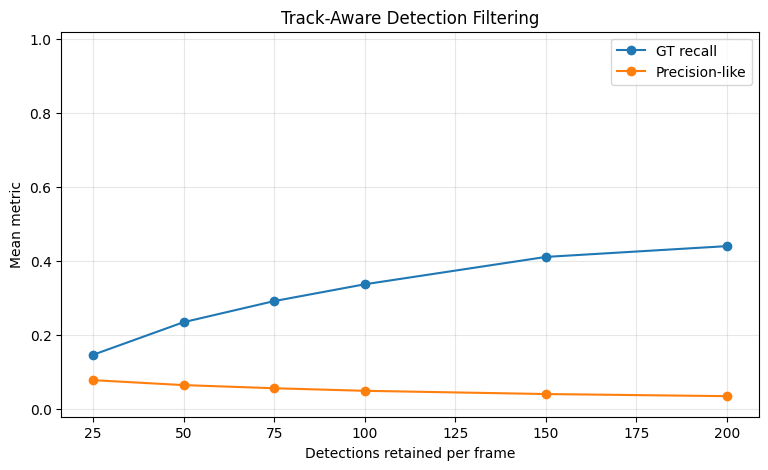

In [13]:

if not filter_summary_df.empty:
    plt.figure(figsize=(9, 5))
    plt.plot(
        filter_summary_df["keep_count"],
        filter_summary_df["mean_gt_recall"],
        marker="o",
        label="GT recall",
    )
    plt.plot(
        filter_summary_df["keep_count"],
        filter_summary_df["mean_precision_like"],
        marker="o",
        label="Precision-like",
    )
    plt.title("Track-Aware Detection Filtering")
    plt.xlabel("Detections retained per frame")
    plt.ylabel("Mean metric")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Step 9 — Train an Optional Temporal Classifier


In [14]:

TEMPORAL_MODEL_FEATURES = [
    "rank_position", "pred_dist", "num_detections", "duration",
    "mean_rank", "mean_pred_dist", "path_length_physical",
    "net_displacement_physical", "track_path_efficiency",
    "track_coverage_fraction", "has_incoming_link", "has_outgoing_link",
    "two_sided_support", "incoming_assignment_cost",
    "outgoing_assignment_cost", "incoming_frame_gap", "outgoing_frame_gap",
    "previous_step_length", "next_step_length", "previous_speed", "next_speed",
    "local_acceleration", "direction_cosine", "temporal_support_score",
]


def train_temporal_filter_model(
    feature_table: pd.DataFrame,
    config: FilteringConfig = CONFIG,
):
    train_df = feature_table[
        feature_table["t"].isin(config.train_timepoints)
    ].copy()
    validation_df = feature_table[
        feature_table["t"].isin(config.validation_timepoints)
    ].copy()

    if train_df.empty or int(train_df["oracle_good"].sum()) == 0:
        print("Not enough positive labels to train the temporal model.")
        return None, pd.DataFrame()

    x_train = (
        train_df[TEMPORAL_MODEL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    y_train = train_df["oracle_good"].astype(int)

    positive_count = int(y_train.sum())
    negative_count = int(len(y_train) - positive_count)
    positive_weight = negative_count / max(positive_count, 1)
    sample_weight = np.where(y_train.to_numpy() == 1, positive_weight, 1.0)

    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=config.random_state,
    )
    model.fit(x_train, y_train, sample_weight=sample_weight)

    rows = []
    if not validation_df.empty and validation_df["oracle_good"].nunique() > 1:
        x_validation = (
            validation_df[TEMPORAL_MODEL_FEATURES]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
        )
        probability = model.predict_proba(x_validation)[:, 1]
        rows.append({
            "split": "validation",
            "rows": len(validation_df),
            "positive_rows": int(validation_df["oracle_good"].sum()),
            "average_precision": average_precision_score(
                validation_df["oracle_good"].astype(int), probability
            ),
        })

    return model, pd.DataFrame(rows)


temporal_model, temporal_model_metrics_df = train_temporal_filter_model(
    feature_df,
    CONFIG,
)

display(temporal_model_metrics_df)


,split,rows,positive_rows,average_precision
0,validation,8000,156,0.023246


In [15]:

if temporal_model is not None:
    model_input = (
        feature_df[TEMPORAL_MODEL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    feature_df["temporal_model_probability"] = temporal_model.predict_proba(
        model_input
    )[:, 1]
    feature_df["final_filter_score"] = (
        0.60 * feature_df["temporal_model_probability"]
        + 0.40 * feature_df["temporal_support_score"]
    )
else:
    feature_df["temporal_model_probability"] = np.nan
    feature_df["final_filter_score"] = feature_df["temporal_support_score"]


display(feature_df[[
    "detection_id", "t", "temporal_support_score",
    "temporal_model_probability", "final_filter_score"
]].sort_values("final_filter_score", ascending=False).head(20))


,detection_id,t,temporal_support_score,temporal_model_probability,final_filter_score
8200,chapter34_t41_0,41,0.722122,0.944917,0.855799
8007,chapter34_t40_7,40,0.716882,0.944917,0.853703
4005,chapter34_t20_5,20,0.714333,0.944917,0.852684
8010,chapter34_t40_10,40,0.710776,0.944917,0.851261
8004,chapter34_t40_4,40,0.706456,0.944917,0.849533
19200,chapter34_t96_0,96,0.699129,0.944917,0.846602
8023,chapter34_t40_23,40,0.696344,0.945161,0.845634
13400,chapter34_t67_0,67,0.691865,0.944917,0.843696
8014,chapter34_t40_14,40,0.690615,0.944917,0.843196
200,chapter34_t1_0,1,0.673831,0.944917,0.836483


## Step 10 — Select the Filtered Detections

The default retains 25% of the 200 candidates in each frame, or approximately 50 detections per frame.


In [16]:

def select_filtered_detections(
    feature_table: pd.DataFrame,
    keep_fraction: float,
) -> pd.DataFrame:
    selected_tables = []

    for timepoint, group in feature_table.groupby("t", sort=True):
        keep_count = max(1, int(round(len(group) * keep_fraction)))
        selected = (
            group
            .sort_values("final_filter_score", ascending=False)
            .head(keep_count)
            .copy()
        )
        selected["filtered_rank_position"] = np.arange(
            1, len(selected) + 1, dtype=np.int32
        )
        selected_tables.append(selected)

    return pd.concat(selected_tables, ignore_index=True)


filtered_detections_df = select_filtered_detections(
    feature_df,
    CONFIG.keep_fraction,
)

print("Filtered detections:", len(filtered_detections_df))
print(
    "Mean detections per frame:",
    filtered_detections_df.groupby("t").size().mean(),
)

display(filtered_detections_df[[
    "t", "detection_id", "z", "y", "x", "rank_position",
    "filtered_rank_position", "final_filter_score"
]].head())


Filtered detections: 5000
Mean detections per frame: 50.0


,t,detection_id,z,y,x,rank_position,filtered_rank_position,final_filter_score
0,0,chapter34_t0_16,7,241,51,17,1,0.807498
1,0,chapter34_t0_17,27,212,110,18,2,0.806073
2,0,chapter34_t0_10,38,192,91,11,3,0.804284
3,0,chapter34_t0_19,37,196,98,20,4,0.799660
4,0,chapter34_t0_0,41,130,131,1,5,0.798578


## Step 11 — Build the Filtered Preliminary Track Graph


In [17]:

def build_filtered_track_graph(
    filtered_detections: pd.DataFrame,
    track_nodes: pd.DataFrame,
    track_edges: pd.DataFrame,
):
    kept_ids = set(filtered_detections["detection_id"])

    filtered_nodes = (
        track_nodes[
            track_nodes["detection_id"].isin(kept_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    if track_edges.empty:
        filtered_edges = track_edges.copy()
    else:
        filtered_edges = (
            track_edges[
                track_edges["source_detection_id"].isin(kept_ids)
                & track_edges["target_detection_id"].isin(kept_ids)
            ]
            .copy()
            .reset_index(drop=True)
        )

    return filtered_nodes, filtered_edges


filtered_track_nodes_df, filtered_track_edges_df = build_filtered_track_graph(
    filtered_detections_df,
    track_nodes_df,
    track_edges_df,
)

print("Filtered track nodes:", len(filtered_track_nodes_df))
print("Filtered track edges:", len(filtered_track_edges_df))


Filtered track nodes: 5000
Filtered track edges: 2971


In [18]:

def summarize_filtered_tracks(filtered_nodes: pd.DataFrame) -> pd.DataFrame:
    if filtered_nodes.empty:
        return pd.DataFrame()

    rows = []
    for track_id, group in filtered_nodes.groupby("track_id", sort=True):
        group = group.sort_values("t").reset_index(drop=True)
        duration = int(group["t"].max() - group["t"].min() + 1)
        rows.append({
            "track_id": int(track_id),
            "start_t": int(group["t"].min()),
            "end_t": int(group["t"].max()),
            "num_filtered_detections": len(group),
            "filtered_duration": duration,
            "filtered_coverage_fraction": len(group) / max(duration, 1),
            "mean_rank_position": float(group["rank_position"].mean()),
            "mean_pred_dist": float(group["pred_dist"].mean()),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("num_filtered_detections", ascending=False)
        .reset_index(drop=True)
    )


filtered_track_summary_df = summarize_filtered_tracks(
    filtered_track_nodes_df
)

display(filtered_track_summary_df.head(30))


,track_id,start_t,end_t,num_filtered_detections,filtered_duration,filtered_coverage_fraction,mean_rank_position,mean_pred_dist
0,668,13,47,24,35,0.685714,61.250000,15.717054
1,1212,29,54,21,26,0.807692,78.904762,16.438339
2,1329,33,61,19,29,0.655172,80.789474,16.217898
3,1184,31,57,19,27,0.703704,89.894737,16.468750
4,1892,50,85,18,36,0.500000,49.333333,14.668612
5,651,13,40,18,28,0.642857,79.888889,15.979721
6,889,20,61,18,42,0.428571,81.500000,16.495176
7,893,20,50,18,31,0.580645,80.666667,16.393109
8,2544,69,99,17,31,0.548387,84.294118,15.611658
9,732,15,35,17,21,0.809524,58.882353,15.525601


## Step 12 — Compare Before and After Filtering


In [19]:

comparison_df = pd.DataFrame({
    "stage": ["chapter34_top200", "chapter36_filtered"],
    "detections": [len(detections_df), len(filtered_detections_df)],
    "mean_detections_per_frame": [
        detections_df.groupby("t").size().mean(),
        filtered_detections_df.groupby("t").size().mean(),
    ],
    "track_nodes": [len(track_nodes_df), len(filtered_track_nodes_df)],
    "track_edges": [len(track_edges_df), len(filtered_track_edges_df)],
    "tracks_with_nodes": [
        track_nodes_df["track_id"].nunique(),
        filtered_track_nodes_df["track_id"].nunique(),
    ],
})

display(comparison_df)


,stage,detections,mean_detections_per_frame,track_nodes,track_edges,tracks_with_nodes
0,chapter34_top200,20000,200.0,20000,16455,3545
1,chapter36_filtered,5000,50.0,5000,2971,1340


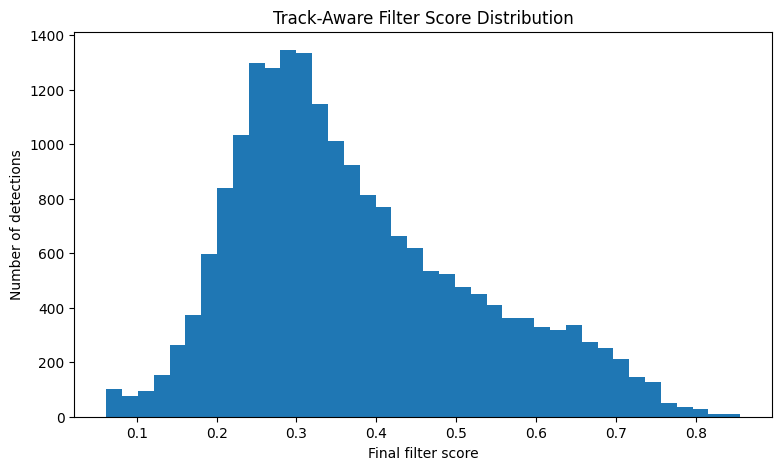

In [20]:

plt.figure(figsize=(9, 5))
plt.hist(feature_df["final_filter_score"], bins=40)
plt.title("Track-Aware Filter Score Distribution")
plt.xlabel("Final filter score")
plt.ylabel("Number of detections")
plt.show()


## Step 13 — Validate the Filtered Output


In [21]:

def validate_filtered_output(
    filtered_detections: pd.DataFrame,
) -> pd.DataFrame:
    if filtered_detections["detection_id"].duplicated().any():
        raise ValueError("Filtered detection IDs are not unique.")

    rows = []
    for timepoint, group in filtered_detections.groupby("t", sort=True):
        expected_rank = np.arange(1, len(group) + 1)
        actual_rank = (
            group
            .sort_values("filtered_rank_position")["filtered_rank_position"]
            .to_numpy()
        )
        rows.append({
            "t": int(timepoint),
            "num_filtered": len(group),
            "unique_coordinates": int(
                group[["z", "y", "x"]].drop_duplicates().shape[0]
            ),
            "filtered_rank_valid": np.array_equal(expected_rank, actual_rank),
        })

    validation_df = pd.DataFrame(rows)
    if not validation_df["filtered_rank_valid"].all():
        raise ValueError("Filtered rank positions are invalid.")

    return validation_df


filter_validation_df = validate_filtered_output(
    filtered_detections_df
)

print("Filtered output validation passed.")
display(filter_validation_df.head())


Filtered output validation passed.


,t,num_filtered,unique_coordinates,filtered_rank_valid
0,0,50,50,True
1,1,50,50,True
2,2,50,50,True
3,3,50,50,True
4,4,50,50,True


## Step 14 — Save Chapter 36 Outputs


In [22]:

output_dir = Path("/kaggle/working")

paths = {
    "detection_features": output_dir / "chapter36_detection_features.csv",
    "filtered_detections": output_dir / "chapter36_filtered_detections.csv",
    "filtered_track_nodes": output_dir / "chapter36_filtered_track_nodes.csv",
    "filtered_track_edges": output_dir / "chapter36_filtered_track_edges.csv",
    "filtered_track_summary": output_dir / "chapter36_filtered_track_summary.csv",
    "filter_evaluation": output_dir / "chapter36_filter_evaluation.csv",
    "filter_validation": output_dir / "chapter36_filter_validation.csv",
    "temporal_model_metrics": output_dir / "chapter36_temporal_model_metrics.csv",
}

feature_df.to_csv(paths["detection_features"], index=False)
filtered_detections_df.to_csv(paths["filtered_detections"], index=False)
filtered_track_nodes_df.to_csv(paths["filtered_track_nodes"], index=False)
filtered_track_edges_df.to_csv(paths["filtered_track_edges"], index=False)
filtered_track_summary_df.to_csv(paths["filtered_track_summary"], index=False)
filter_evaluation_df.to_csv(paths["filter_evaluation"], index=False)
filter_validation_df.to_csv(paths["filter_validation"], index=False)
temporal_model_metrics_df.to_csv(paths["temporal_model_metrics"], index=False)

for name, path in paths.items():
    print(f"Saved {name}: {path}")


Saved detection_features: /kaggle/working/chapter36_detection_features.csv
Saved filtered_detections: /kaggle/working/chapter36_filtered_detections.csv
Saved filtered_track_nodes: /kaggle/working/chapter36_filtered_track_nodes.csv
Saved filtered_track_edges: /kaggle/working/chapter36_filtered_track_edges.csv
Saved filtered_track_summary: /kaggle/working/chapter36_filtered_track_summary.csv
Saved filter_evaluation: /kaggle/working/chapter36_filter_evaluation.csv
Saved filter_validation: /kaggle/working/chapter36_filter_validation.csv
Saved temporal_model_metrics: /kaggle/working/chapter36_temporal_model_metrics.csv


# What You Need to Save

Yes. Save the outputs from this lesson before starting Chapter 37.

## Required

```text
chapter36_filtered_detections.csv
```

This is the clean detection table that the next tracking or division notebook should use.

## Strongly recommended

```text
chapter36_detection_features.csv
chapter36_filtered_track_nodes.csv
chapter36_filtered_track_edges.csv
```

`chapter36_detection_features.csv` is especially important because it preserves every temporal feature and score. Saving it prevents you from having to rerun Chapters 34–36 when testing another threshold.

## Diagnostic only

```text
chapter36_filtered_track_summary.csv
chapter36_filter_evaluation.csv
chapter36_filter_validation.csv
chapter36_temporal_model_metrics.csv
```

After the notebook finishes, use **Save Version → Save & Run All (Commit)** so the `/kaggle/working` files are preserved with the notebook version.
